# Notebook 02: Sentiment Analysis

**Goal:** Run FinBERT on real financial news headlines and understand the sentiment signal.

What this notebook covers:
1. Load real news articles from NewsAPI
2. Run FinBERT on individual headlines — see raw scores
3. Aggregate sentiment per ticker (positive/neutral/negative distribution)
4. Visualize sentiment scores across tickers
5. Compare sentiment signal vs recent stock price movement
6. Retrieve semantically similar articles from FAISS per ticker
7. Summary: which tickers have strongest signal?


In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dotenv import load_dotenv

load_dotenv('../.env')

# FIX: Create plots directory before any savefig calls
os.makedirs('../data/plots', exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
print('Setup complete.')

Setup complete.


---
## Section 1: Load News Data

In [2]:
# ── 1.1 Fetch news articles for all tickers ───────────────────────────────────
from src.data.news_fetcher import fetch_news

all_news = {}
for ticker in TICKERS:
    articles = fetch_news(ticker)
    all_news[ticker] = articles
    print(f'{ticker}: {len(articles)} articles fetched')

print(f'\nTotal articles: {sum(len(v) for v in all_news.values())}')

2026-07-26 15:31:05,844 - INFO - Fetching news for AAPL (query: 'AAPL stock')
2026-07-26 15:31:09,431 - INFO - Found 18 articles for AAPL
2026-07-26 15:31:09,434 - INFO - Fetching news for MSFT (query: 'MSFT stock')


AAPL: 18 articles fetched


2026-07-26 15:31:14,073 - INFO - Found 19 articles for MSFT
2026-07-26 15:31:14,076 - INFO - Fetching news for GOOGL (query: 'GOOGL stock')


MSFT: 19 articles fetched


2026-07-26 15:31:14,653 - INFO - Found 19 articles for GOOGL
2026-07-26 15:31:14,657 - INFO - Fetching news for AMZN (query: 'AMZN stock')


GOOGL: 19 articles fetched


2026-07-26 15:31:15,282 - INFO - Found 19 articles for AMZN


AMZN: 19 articles fetched

Total articles: 75


In [3]:
# ── 1.2 Extract headlines per ticker ─────────────────────────────────────────
headlines = {}
for ticker, articles in all_news.items():
    headlines[ticker] = [
        a.get('title', '') for a in articles
        if a.get('title') and len(a.get('title', '')) > 10
    ]
    print(f'{ticker}: {len(headlines[ticker])} usable headlines')

print('\nSample headlines (AAPL):')
for h in headlines.get('AAPL', [])[:5]:
    print(f'  - {h}')

AAPL: 18 usable headlines
MSFT: 19 usable headlines
GOOGL: 19 usable headlines
AMZN: 19 usable headlines

Sample headlines (AAPL):
  - Apple Stock Sends Major Warning Signal as Momentum Hits Peak
  - Kraken parent expands tokenized stocks to Hong Kong, UK and South Korea equities
  - The Cost Pressure Apple Stock Stopped Flagging, And The New One That Should Worry You
  - Is Apple stock overvalued? Here's what AlphaSpace valuation metrics say.
  - Why Worried Investors Should Buy Apple Over Amazon for the Rest of 2026


---
## Section 2: FinBERT Sentiment on Individual Headlines

In [4]:
# ── 2.1 Load FinBERT model ────────────────────────────────────────────────────
# This uses the cached model from Day 4 (~500MB, no re-download needed)
#
# FIX: sentiment.py exposes get_sentiment_score() as a module-level function.
# Import it directly — if your sentiment.py uses a class, wrap it here.
from src.models.sentiment import get_sentiment_score, aggregate_sentiment

print('FinBERT model loading...')
# Test on a few sample sentences first
test_sentences = [
    'Apple reports record earnings, beating analyst expectations by 15%',
    'Microsoft faces regulatory scrutiny over cloud monopoly concerns',
    'Google announces new AI product at annual developer conference',
    'Amazon stock falls after disappointing holiday season guidance',
    'Tech stocks rally as inflation fears ease'
]

print('\nFinBERT test on sample sentences:')
print(f'{"Headline":<65} {"Score":>8} {"Label"}')
print('─' * 90)
for sentence in test_sentences:
    score = get_sentiment_score(sentence)
    label = 'Positive' if score >= 0.3 else ('Negative' if score <= -0.3 else 'Neutral')
    display = sentence[:62] + '...' if len(sentence) > 65 else sentence
    print(f'{display:<65} {score:>+8.3f} {label}')

2026-07-26 15:31:18,411 - INFO - Loading FinBERT model: ProsusAI/finbert
2026-07-26 15:31:18,412 - INFO - First run downloads ~500MB — please wait...


FinBERT model loading...

FinBERT test on sample sentences:
Headline                                                             Score Label
──────────────────────────────────────────────────────────────────────────────────────────


2026-07-26 15:31:20,333 - INFO - FinBERT loaded successfully


Apple reports record earnings, beating analyst expectations by...   +0.920 Positive
Microsoft faces regulatory scrutiny over cloud monopoly concerns    -0.943 Negative
Google announces new AI product at annual developer conference      +0.243 Neutral
Amazon stock falls after disappointing holiday season guidance      -0.945 Negative
Tech stocks rally as inflation fears ease                           -0.387 Negative


In [5]:
# ── 2.2 Run FinBERT on ALL headlines for each ticker ─────────────────────────
# This may take 30-60 seconds depending on number of articles
print('Running FinBERT on all headlines...')
per_article_scores = {}   # {ticker: [(headline, score, label), ...]}

for ticker in TICKERS:
    ticker_headlines = headlines.get(ticker, [])
    scores = []
    for h in ticker_headlines:
        score = get_sentiment_score(h)
        label = 'Positive' if score >= 0.3 else ('Negative' if score <= -0.3 else 'Neutral')
        scores.append((h, score, label))
    per_article_scores[ticker] = scores
    print(f'  {ticker}: {len(scores)} headlines scored')

print('\nDone.')

Running FinBERT on all headlines...
  AAPL: 18 headlines scored
  MSFT: 19 headlines scored
  GOOGL: 19 headlines scored
  AMZN: 19 headlines scored

Done.


In [6]:
# ── 2.3 Show top positive and negative headlines per ticker ───────────────────
for ticker in TICKERS:
    scores = per_article_scores.get(ticker, [])
    if not scores:
        continue
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)
    print(f'\n{ticker}:')
    print('  Most Positive:')
    for h, s, l in sorted_scores[:2]:
        print(f'    [{s:+.3f}] {h[:80]}')
    print('  Most Negative:')
    for h, s, l in sorted_scores[-2:]:
        print(f'    [{s:+.3f}] {h[:80]}')


AAPL:
  Most Positive:
    [+0.913] Taiwan Semi Is Raising Wafer Manufacturing Prices. Why That’s Good News for TSM 
    [+0.856] Will Ternus split AAPL? Apple stock split buzz returns near record highs
  Most Negative:
    [-0.889] Bank of America doubles down on Apple stock ahead of earnings
    [-0.890] Experts Warned This Would Be a Volatile Earnings Season. So Far They’re Right.

MSFT:
  Most Positive:
    [+0.873] AMD CEO Lisa Su on AI demand and hyperscaler spending: 'We're seeing the returns
    [+0.729] TSMC Stock: A $64 Billion Bet Even as AI Bubble Fears Grow
  Most Negative:
    [-0.887] Stock Indexes Mixed Ahead of Alphabet’s Earnings
    [-0.958] Oracle stock has crashed 50% since June

GOOGL:
  Most Positive:
    [+0.787] Google's profits are outrunning its AI spending boom: AlphaCheck
    [+0.483] AMD, Micron, SK Hynix climb as semiconductor complex attempt recovery
  Most Negative:
    [-0.953] Markets News, July 23, 2026: Stocks Close Sharply Lower as Alphabet, Tesla

---
## Section 3: Aggregate Sentiment Per Ticker

In [7]:
# ── 3.1 Aggregate scores per ticker ──────────────────────────────────────────
agg_scores = {}

for ticker in TICKERS:
    ticker_headlines = headlines.get(ticker, [])

    if ticker_headlines:
        agg_scores[ticker] = aggregate_sentiment(ticker_headlines)
    else:
        agg_scores[ticker] = 0.0

print('Aggregated Sentiment Scores:')
print(f'{"Ticker":<8} {"Score":>8} {"Label"}')
print('─' * 30)
for ticker, score in agg_scores.items():
    label = 'Positive' if score >= 0.3 else ('Negative' if score <= -0.3 else 'Neutral')
    bar = '█' * int(abs(score) * 20)
    sign = '+' if score >= 0 else ''
    print(f'{ticker:<8} {sign}{score:>7.3f} {label}  {bar}')

2026-07-26 15:31:24,168 - INFO - Analyzed 5/18 articles
2026-07-26 15:31:24,381 - INFO - Analyzed 10/18 articles
2026-07-26 15:31:24,614 - INFO - Analyzed 15/18 articles
2026-07-26 15:31:24,968 - INFO - Analyzed 5/19 articles
2026-07-26 15:31:25,184 - INFO - Analyzed 10/19 articles
2026-07-26 15:31:25,418 - INFO - Analyzed 15/19 articles
2026-07-26 15:31:25,798 - INFO - Analyzed 5/19 articles
2026-07-26 15:31:26,016 - INFO - Analyzed 10/19 articles
2026-07-26 15:31:26,225 - INFO - Analyzed 15/19 articles
2026-07-26 15:31:26,589 - INFO - Analyzed 5/19 articles
2026-07-26 15:31:26,797 - INFO - Analyzed 10/19 articles
2026-07-26 15:31:27,020 - INFO - Analyzed 15/19 articles


Aggregated Sentiment Scores:
Ticker      Score Label
──────────────────────────────
AAPL     +  0.195 Neutral  ███
MSFT     +  0.036 Neutral  
GOOGL     -0.155 Neutral  ███
AMZN      -0.200 Neutral  ███


In [8]:
# ── 3.2 Sentiment distribution (positive/neutral/negative ratio) ──────────────
distribution = {}
for ticker in TICKERS:
    scores = per_article_scores.get(ticker, [])
    if not scores:
        distribution[ticker] = {'Positive': 0, 'Neutral': 0, 'Negative': 0}
        continue
    pos = sum(1 for _, s, _ in scores if s >= 0.3)
    neg = sum(1 for _, s, _ in scores if s <= -0.3)
    neu = len(scores) - pos - neg
    distribution[ticker] = {'Positive': pos, 'Neutral': neu, 'Negative': neg}

print('\nSentiment Distribution per Ticker:')
for ticker, dist in distribution.items():
    total = sum(dist.values())
    if total == 0:
        continue
    print(f'{ticker}: Positive={dist["Positive"]} | Neutral={dist["Neutral"]} | Negative={dist["Negative"]}')


Sentiment Distribution per Ticker:
AAPL: Positive=7 | Neutral=9 | Negative=2
MSFT: Positive=3 | Neutral=14 | Negative=2
GOOGL: Positive=3 | Neutral=10 | Negative=6
AMZN: Positive=1 | Neutral=12 | Negative=6


---
## Section 4: Visualizations

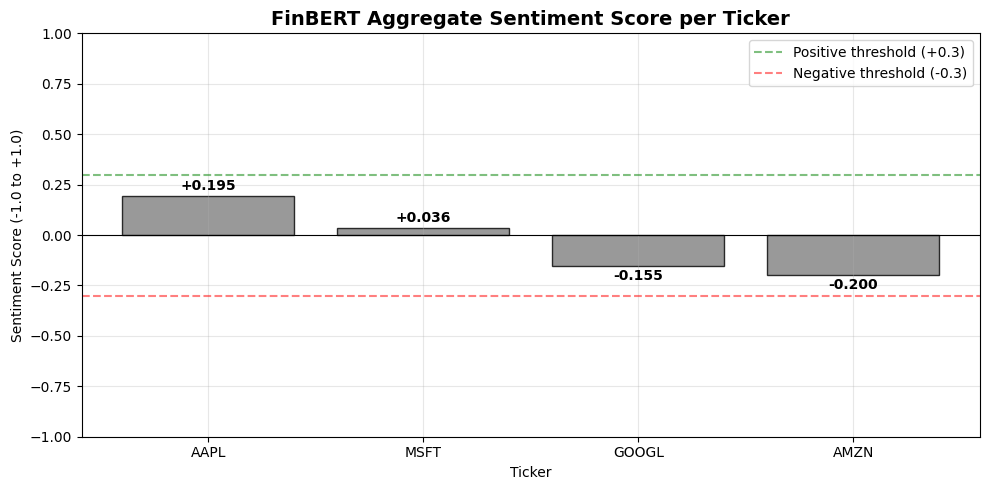

Saved: data/plots/02_sentiment_scores.png


In [9]:
# ── 4.1 Bar chart: Aggregate sentiment scores ─────────────────────────────────
colors = ['green' if v >= 0.3 else ('red' if v <= -0.3 else 'gray')
          for v in agg_scores.values()]

plt.figure(figsize=(10, 5))
bars = plt.bar(agg_scores.keys(), agg_scores.values(), color=colors, alpha=0.8, edgecolor='black')
plt.axhline(y=0.3,  color='green', linestyle='--', alpha=0.5, label='Positive threshold (+0.3)')
plt.axhline(y=-0.3, color='red',   linestyle='--', alpha=0.5, label='Negative threshold (-0.3)')
plt.axhline(y=0,    color='black', linewidth=0.8)
plt.ylim(-1.0, 1.0)
plt.title('FinBERT Aggregate Sentiment Score per Ticker', fontsize=14, fontweight='bold')
plt.ylabel('Sentiment Score (-1.0 to +1.0)')
plt.xlabel('Ticker')
plt.legend()
for bar, val in zip(bars, agg_scores.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (0.03 if val >= 0 else -0.07),
        f'{val:+.3f}', ha='center', fontweight='bold'
    )
plt.tight_layout()
plt.savefig('../data/plots/02_sentiment_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/02_sentiment_scores.png')

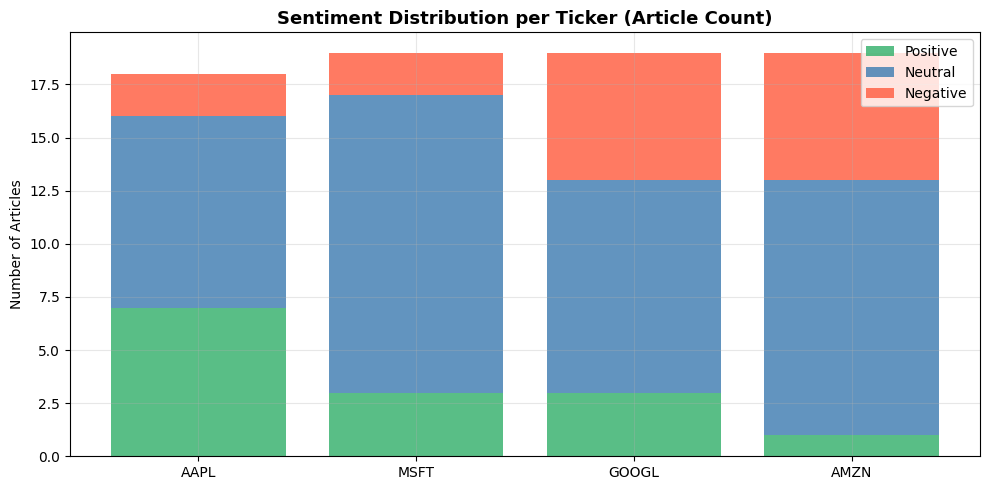

Saved: data/plots/02_sentiment_distribution.png


In [10]:
# ── 4.2 Stacked bar: Sentiment distribution breakdown ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

tickers_list = list(distribution.keys())
pos_vals = [distribution[t]['Positive'] for t in tickers_list]
neu_vals = [distribution[t]['Neutral']  for t in tickers_list]
neg_vals = [distribution[t]['Negative'] for t in tickers_list]

x = range(len(tickers_list))
ax.bar(x, pos_vals, label='Positive', color='mediumseagreen', alpha=0.85)
ax.bar(x, neu_vals, bottom=pos_vals, label='Neutral', color='steelblue', alpha=0.85)
ax.bar(x, neg_vals,
       bottom=[p + n for p, n in zip(pos_vals, neu_vals)],
       label='Negative', color='tomato', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(tickers_list)
ax.set_title('Sentiment Distribution per Ticker (Article Count)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Articles')
ax.legend()
plt.tight_layout()
plt.savefig('../data/plots/02_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/02_sentiment_distribution.png')

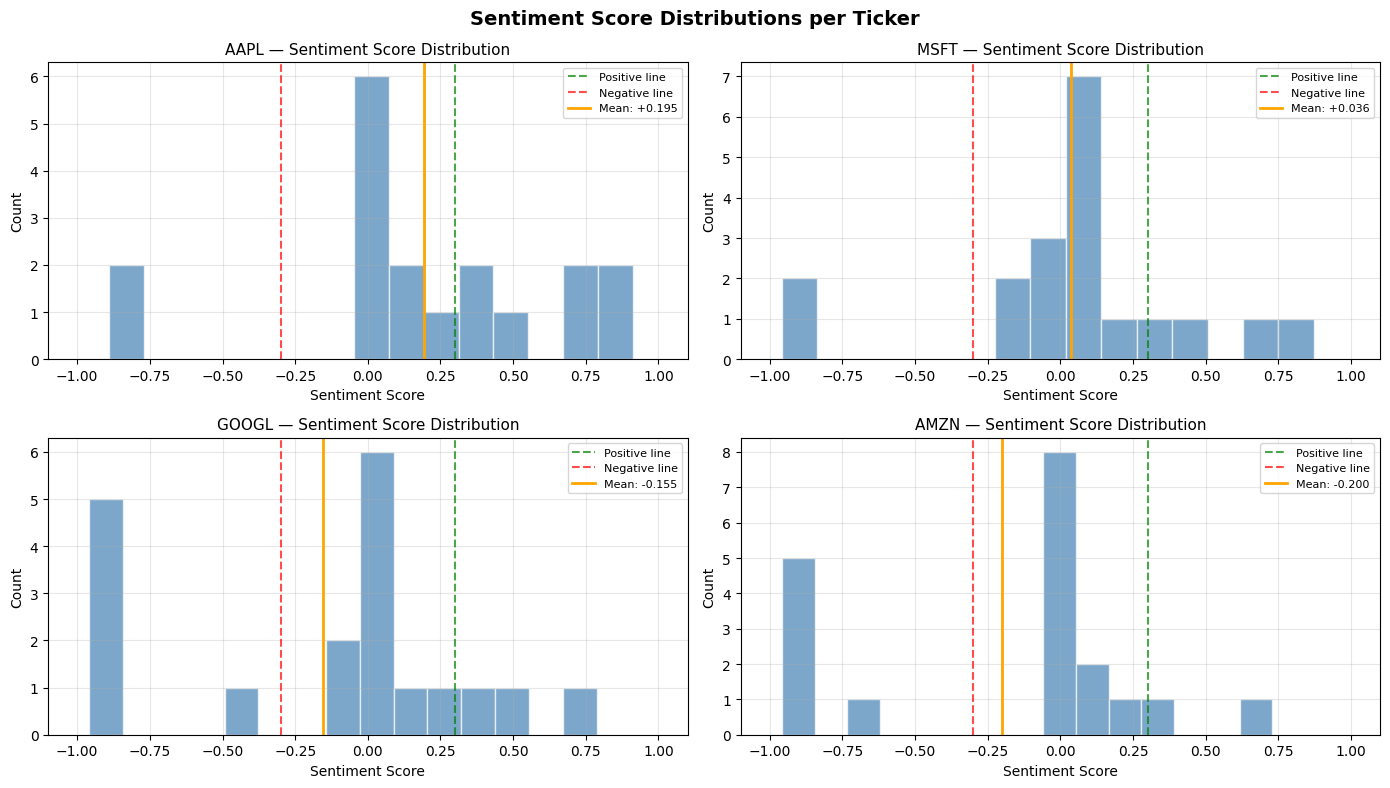

Saved: data/plots/02_score_distributions.png


In [11]:
# ── 4.3 Score distribution histogram per ticker ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    scores_only = [s for _, s, _ in per_article_scores.get(ticker, [])]
    if not scores_only:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        continue

    axes[i].hist(scores_only, bins=15, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].axvline(x=0.3,  color='green',  linestyle='--', alpha=0.7, label='Positive line')
    axes[i].axvline(x=-0.3, color='red',    linestyle='--', alpha=0.7, label='Negative line')
    axes[i].axvline(
        x=np.mean(scores_only), color='orange', linewidth=2,
        label=f'Mean: {np.mean(scores_only):+.3f}'
    )
    axes[i].set_title(f'{ticker} — Sentiment Score Distribution', fontsize=11)
    axes[i].set_xlabel('Sentiment Score')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(-1.1, 1.1)

plt.suptitle('Sentiment Score Distributions per Ticker', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plots/02_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/02_score_distributions.png')

---
## Section 5: Sentiment vs Price Movement

In [12]:
# ── 5.1 Fetch recent price data and compare to sentiment ──────────────────────
from src.data.stock_fetcher import fetch_stock_data

prices = fetch_stock_data(TICKERS)
# FIX: flatten MultiIndex consistently
if isinstance(prices.columns, pd.MultiIndex):
    prices = prices['Close']

# Recent 30-day return per ticker
recent_returns = {}
for ticker in TICKERS:
    if ticker in prices.columns:
        col = prices[ticker].dropna()
        if len(col) >= 30:
            ret_30d = (col.iloc[-1] - col.iloc[-30]) / col.iloc[-30]
        elif len(col) > 1:
            ret_30d = (col.iloc[-1] - col.iloc[0]) / col.iloc[0]
        else:
            ret_30d = 0.0
        recent_returns[ticker] = round(float(ret_30d) * 100, 2)

print('30-day Price Return vs Sentiment Score:')
print(f'{"Ticker":<8} {"30d Return":>12} {"Sentiment":>12} {"Aligned?"}')
print('─' * 45)
for ticker in TICKERS:
    ret  = recent_returns.get(ticker, 0)
    sent = agg_scores.get(ticker, 0)
    aligned = '✅' if (ret > 0 and sent > 0) or (ret < 0 and sent < 0) else '❌ Diverge'
    print(f'{ticker:<8} {ret:>+11.2f}% {sent:>+12.3f} {aligned}')

2026-07-26 15:31:29,559 - INFO - Fetching price data for ['AAPL', 'MSFT', 'GOOGL', 'AMZN'] | period=1mo
2026-07-26 15:31:31,410 - INFO - Successfully fetched 21 rows for ['AAPL', 'AMZN', 'GOOGL', 'MSFT']


30-day Price Return vs Sentiment Score:
Ticker     30d Return    Sentiment Aligned?
─────────────────────────────────────────────
AAPL          +21.03%       +0.195 ✅
MSFT           +8.18%       +0.036 ✅
GOOGL          -6.97%       -0.155 ✅
AMZN           +2.25%       -0.200 ❌ Diverge


C:\Users\HP\AppData\Local\Temp\ipykernel_9788\2190792717.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_9788\2190792717.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_9788\2190792717.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig('../data/plots/02_sentiment_vs_return.png', dpi=150, bbox_inches='tight')
d:\GitHub Project\AI-Powered-Portfolio-Optimizer\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


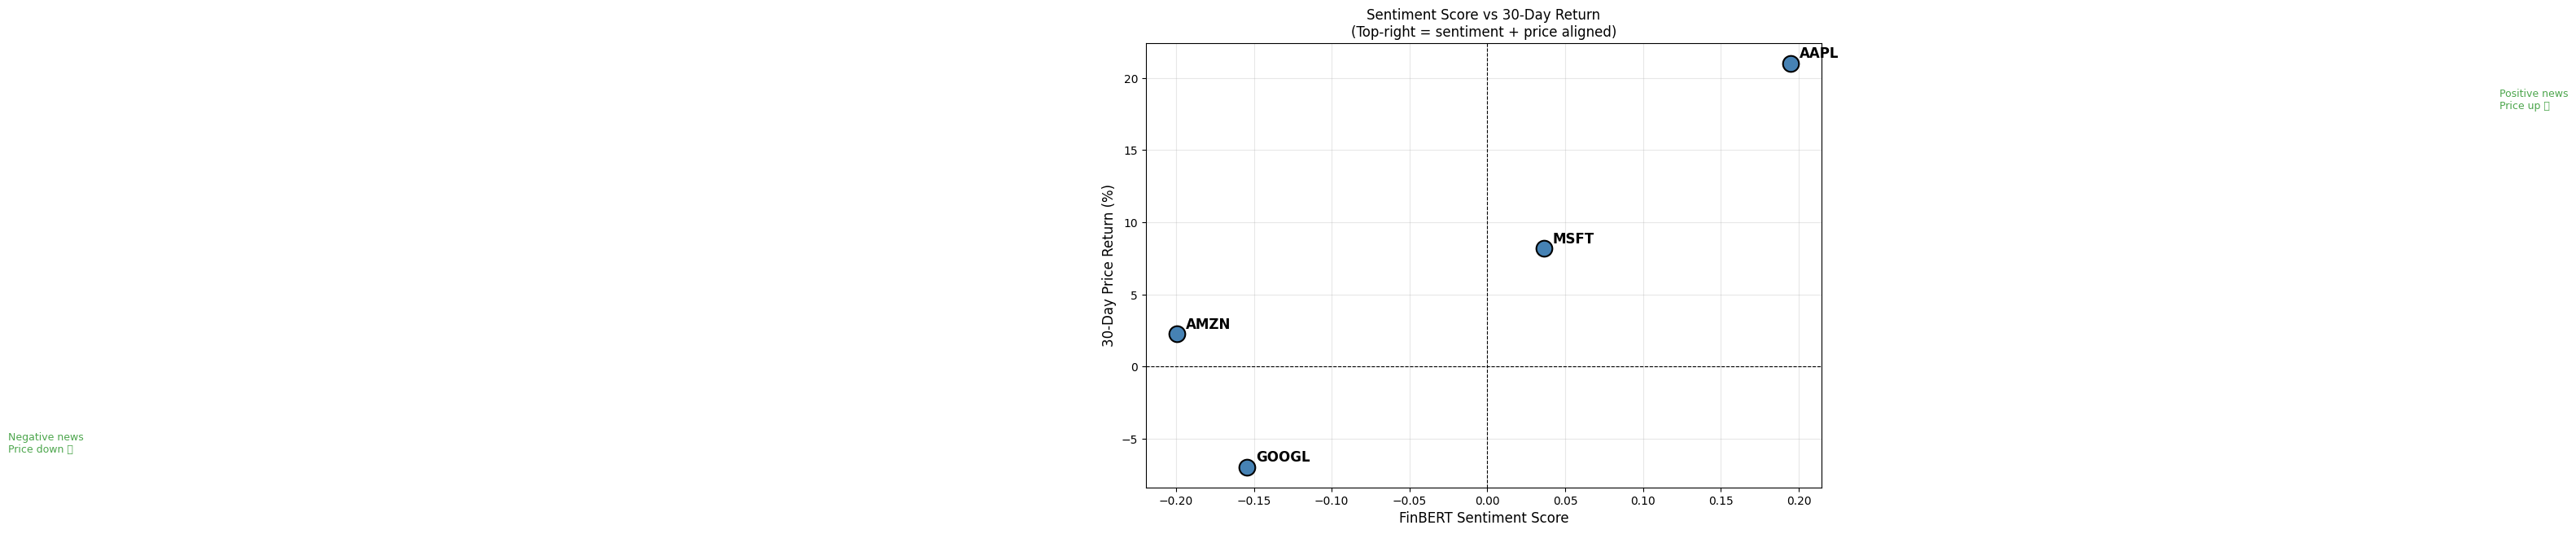

Saved: data/plots/02_sentiment_vs_return.png


In [13]:
# ── 5.2 Scatter plot: Sentiment vs 30-day return ──────────────────────────────
tickers_to_plot = [t for t in TICKERS if t in recent_returns]
x = [agg_scores.get(t, 0)      for t in tickers_to_plot]
y = [recent_returns.get(t, 0)  for t in tickers_to_plot]

plt.figure(figsize=(10, 7))
plt.scatter(x, y, s=200, zorder=5, color='steelblue', edgecolors='black', linewidth=1.5)

for i, ticker in enumerate(tickers_to_plot):
    plt.annotate(ticker, (x[i], y[i]),
                 textcoords='offset points', xytext=(8, 5),
                 fontsize=12, fontweight='bold')

plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('FinBERT Sentiment Score', fontsize=12)
plt.ylabel('30-Day Price Return (%)', fontsize=12)
plt.title('Sentiment Score vs 30-Day Return\n(Top-right = sentiment + price aligned)', fontsize=12)

# FIX: guard against empty lists and zero-range axes before placing text
if y:
    y_max = max(y) if max(y) != 0 else 1
    y_min = min(y) if min(y) != 0 else -1
    plt.text(0.65,  y_max * 0.85, 'Positive news\nPrice up ✅',   fontsize=9, color='green', alpha=0.7)
    plt.text(-0.95, y_min * 0.85, 'Negative news\nPrice down ✅', fontsize=9, color='green', alpha=0.7)
    
plt.subplots_adjust(left=0.12, right=0.95, top=0.90,bottom=0.12)
plt.tight_layout()
plt.savefig('../data/plots/02_sentiment_vs_return.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/02_sentiment_vs_return.png')

---
## Section 6: FAISS Semantic Search per Ticker

In [14]:
# ── 6.1 Load FAISS index and do semantic retrieval ────────────────────────────
from src.data.vector_store import VectorStore

FAISS_PATH = '../data/faiss_index'
vs = VectorStore()

# FIX: same guard as Notebook 01 — build if missing
index_file = os.path.join(FAISS_PATH, 'index.faiss')
if os.path.exists(index_file):
    vs.load(path=FAISS_PATH)
    print(f'FAISS loaded: {vs.index.ntotal} vectors, {vs.index.d} dimensions')
else:
    print('Index not found — building from current news articles...')
    all_texts = []
    for ticker, articles in all_news.items():
        for article in articles:
            title = article.get('title', '')
            desc  = article.get('description', '')
            if title:
                all_texts.append(f'{ticker}: {title}. {desc}')
    vs.add_documents(all_texts)
    vs.save(path=FAISS_PATH)
    print(f'Built index: {vs.index.ntotal} vectors')

2026-07-26 15:31:33,704 - INFO - Loading faiss with AVX2 support.
2026-07-26 15:31:33,708 - INFO - Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
2026-07-26 15:31:33,710 - INFO - Loading faiss.
2026-07-26 15:31:33,753 - INFO - Successfully loaded faiss.
2026-07-26 15:31:34,993 - INFO - Loading embedding model: all-MiniLM-L6-v2
2026-07-26 15:31:34,994 - INFO - First run downloads ~90MB — please wait...
2026-07-26 15:31:34,996 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2026-07-26 15:31:38,258 - INFO - Use pytorch device_name: cpu
2026-07-26 15:31:38,285 - INFO - Model loaded. Embedding dimension: 384
2026-07-26 15:31:38,295 - INFO - Loaded 77 articles from ../data/faiss_index


FAISS loaded: 77 vectors, 384 dimensions


In [15]:
# ── 6.2 Retrieve top articles per ticker and score them ───────────────────────
print('Semantic retrieval + sentiment for each ticker:')
print('=' * 70)

ticker_queries = {
    'AAPL':  'Apple iPhone revenue earnings growth',
    'MSFT':  'Microsoft Azure cloud AI growth',
    'GOOGL': 'Google search advertising antitrust',
    'AMZN':  'Amazon AWS e-commerce logistics'
}

rag_sentiment = {}
for ticker, query in ticker_queries.items():
    print(f'\n{ticker} — query: "{query}"')
    results = vs.search(query, k=3)
    if results:
        retrieved_texts = [str(r) for r in results]
        rag_score = aggregate_sentiment(retrieved_texts)
        rag_sentiment[ticker] = rag_score
        for j, text in enumerate(retrieved_texts):
            score = get_sentiment_score(text)
            print(f'  [{j+1}] Score: {score:+.3f} | {str(text)[:80]}')
        print(f'  Aggregated RAG sentiment: {rag_score:+.3f}')
    else:
        print('  No results found in FAISS index')
        rag_sentiment[ticker] = 0.0

Semantic retrieval + sentiment for each ticker:

AAPL — query: "Apple iPhone revenue earnings growth"


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-07-26 15:31:38,526 - INFO - Search 'Apple iPhone revenue earnings growth' → 3 results


  [1] Score: -0.364 | Apple Stock Hits Record Territory as Traders Sour on AI Spending. Apple shares h
  [2] Score: -0.364 | Apple Stock Hits Record Territory as Traders Sour on AI Spending. Apple shares h
  [3] Score: -0.364 | Apple Stock Hits Record Territory as Traders Sour on AI Spending. Apple shares h
  Aggregated RAG sentiment: -0.364

MSFT — query: "Microsoft Azure cloud AI growth"


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

2026-07-26 15:31:43,081 - INFO - Search 'Google search advertising antitrust' → 3 results


  [1] Score: -0.000 | Surviving The Impression Squeeze: How Agentic Commerce Is Changing Google Ads In
  [2] Score: +0.806 | Dear Google Stock Fans, Mark Your Calendars for July 13. Google Cloud's new U.K.
  [3] Score: -0.809 | Google Pixel 10 Pro plunges $300 in its best non-Prime deal ever. Amazon cuts th
  Aggregated RAG sentiment: -0.001

AMZN — query: "Amazon AWS e-commerce logistics"


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-07-26 15:31:44,896 - INFO - Search 'Amazon AWS e-commerce logistics' → 3 results


  [1] Score: +0.035 | 10 Weekend Reads. The weekend is here! Pour yourself a mug of Danish Blend coffe
  [2] Score: +0.035 | 10 Weekend Reads. The weekend is here! Pour yourself a mug of Danish Blend coffe
  [3] Score: +0.035 | 10 Weekend Reads. The weekend is here! Pour yourself a mug of Danish Blend coffe
  Aggregated RAG sentiment: +0.035


In [16]:
# ── 6.3 Compare direct sentiment vs RAG-retrieved sentiment ──────────────────
print('\nComparison: Direct Headlines vs RAG-retrieved Sentiment')
print(f'{"Ticker":<8} {"Direct":>10} {"RAG":>10} {"Difference":>12}')
print('─' * 42)
for ticker in TICKERS:
    direct = agg_scores.get(ticker, 0)
    rag    = rag_sentiment.get(ticker, 0)
    diff   = rag - direct
    print(f'{ticker:<8} {direct:>+10.3f} {rag:>+10.3f} {diff:>+12.3f}')


Comparison: Direct Headlines vs RAG-retrieved Sentiment
Ticker       Direct        RAG   Difference
──────────────────────────────────────────
AAPL         +0.195     -0.364       -0.559
MSFT         +0.036     -0.413       -0.450
GOOGL        -0.155     -0.001       +0.154
AMZN         -0.200     +0.035       +0.235


---
## Section 7: Summary

In [17]:
# ── 7.1 Final sentiment summary ───────────────────────────────────────────────
print('=' * 60)
print('SENTIMENT ANALYSIS SUMMARY')
print('=' * 60)

for ticker in TICKERS:
    score     = agg_scores.get(ticker, 0)
    label     = 'Positive' if score >= 0.3 else ('Negative' if score <= -0.3 else 'Neutral')
    n_articles = len(per_article_scores.get(ticker, []))
    print(f'{ticker}: {score:+.3f} ({label}) — {n_articles} articles')

print()
strongest_positive = max(agg_scores, key=agg_scores.get)
strongest_negative = min(agg_scores, key=agg_scores.get)
print(f'Strongest positive signal : {strongest_positive} ({agg_scores[strongest_positive]:+.3f})')
print(f'Strongest negative signal : {strongest_negative} ({agg_scores[strongest_negative]:+.3f})')
print()
print('These scores will feed into:')
print('  → combined_signal.py (blend with Sharpe weights)')
print('  → rag_pipeline.py (passed to LLM for recommendations)')
print()
print('✅ Sentiment analysis complete. Ready for Notebook 03 (optimization).')

SENTIMENT ANALYSIS SUMMARY
AAPL: +0.195 (Neutral) — 18 articles
MSFT: +0.036 (Neutral) — 19 articles
GOOGL: -0.155 (Neutral) — 19 articles
AMZN: -0.200 (Neutral) — 19 articles

Strongest positive signal : AAPL (+0.195)
Strongest negative signal : AMZN (-0.200)

These scores will feed into:
  → combined_signal.py (blend with Sharpe weights)
  → rag_pipeline.py (passed to LLM for recommendations)

✅ Sentiment analysis complete. Ready for Notebook 03 (optimization).
